In [46]:
# Hello! I am a test cell. You can run me to see if your Python environment is working.
# Try pressing 'Ctrl + Enter' and see if you can see the message below.


print("If it is working, it is working. If it is not, it is not.")

If it is working, it is working. If it is not, it is not.


### The Scatter Plot

A scatter plot is a type of plot that presents values for two variables for a set of data using Cartesian coordinates. The data points are displayed as a collection of points, where one variable's value determines the position on the horizontal axis, and the other variable's value determines the position on the vertical axis.

**Use cases:**

- Examine the relationship between two continuous variables.
    - Example: temperature and energy consumption.
- Investigate patterns or trends in data.
    - Example: house prices versus size.
- Detect outliers or unusual observations.
    - Example: outliers in test scores or abnormal stock behavior.
- Visualize data with many observations to identify clusters or groups.
- Explore complex data.

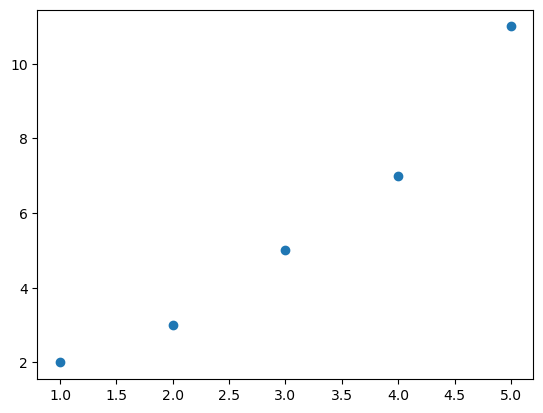

In [47]:
import matplotlib.pyplot as plt 
# import numpy as np
# Let's create simple scatter plot 
x = [1, 2, 3, 4, 5]
y = [2, 3, 5, 7, 11]
plt.scatter(x, y)

# Graph Aesthetics

Almost all the graph aesthetics we have observed with the line plot also apply to the scatter plot. For instance, we can define the color of the points and the markers in the same way we define the color of the lines and markers.

We can also add a nice title to the graph and labels to the axes.

However, there are some aesthetic elements that are particularly necessary in scatter plots. Some of these elements are:

### Alpha

The `alpha` parameter controls the transparency of the plot's elements. It takes a value between 0 and 1, where 0 is completely transparent, and 1 is completely opaque. This setting is useful in scatter plots to manage the overplotting issue when multiple points overlap, making it easier to visualize the density of the data points.

**Example:**

```python
plt.scatter(x, y, alpha=0.5)
plt.title('Scatter Plot with Alpha')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
```

This example creates a scatter plot where the points are semi-transparent, allowing for better visibility of areas with a high density of points.

### The 'c' Color Option

The 'c' parameter in the scatter plot function allows for the coloring of individual points based on a variable's value. This can be particularly useful for showing a third dimension on a 2D scatter plot or for highlighting groups within the data. The color can be specified as a single color format string, or an array of color specifications where each color corresponds to a point.

**Example:**

```python
plt.scatter(x, y, c=z)  # Assuming z is an array of values used for coloring
```

This creates a scatter plot where the colors of the points correspond to the values of the array `z`, with a color bar added to the side to indicate the scale of the values.

### Color Bar

A color bar is a key component in scatter plots when using the 'c' parameter for color coding, as it indicates the scale of the coloring variable. It provides a visual reference to understand the meaning behind the colors of the points, effectively turning a 2D scatter plot into a multidimensional representation of data.

**Example:**

```python
scatter = plt.scatter(x, y, c=z)
# Create colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Value')
cbar.set_ticks(range(1, 13))  # Adjust this line according to your data's specific range
cbar.set_ticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
```

In this example, the color bar is associated with the scatter plot object. The color bar represents the range of values in `z`, allowing the viewer to understand what each color on the scatter plot signifies. This technique is particularly useful for visualizing complex data sets with multiple variables.

### The cmap Option

The `cmap` option allows you to specify a colormap for the scatter plot, which is a range of colors used to map to the `c` parameter's values. This is especially useful when you want to show a gradient of colors that represent a range of data values, providing visual cues about the data distribution.

**Example:**

```python
plt.scatter(x, y, c=z, cmap='Spectral')
plt.colorbar()  # Display color scale
plt.title('Scatter Plot with Colormap')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
```


Matplotlib offers a variety of colormaps you can use to visualize your data. Here's a list of some commonly used colormaps:

- `viridis`
- `plasma`
- `inferno`
- `magma`
- `cividis`
- `coolwarm`
- `Greys`
- `Purples`
- `Blues`
- `Greens`
- `Oranges`
- `Reds`
- `twilight`
- `Pastel1`


==========

#### Example: The Data Science Salaries

In this dataset, we have the salaries of data scientists over the years. It contains several columns, such as `work_year`, `experience_level`, `job_title`, and `salary_in_usd`.

Let's explore this dataset. Our objective is to generate a scatter plot that shows us the relationship between the salary amount and the experience level.

We want to generate a scatter plot to see if there is a trend in terms of the difference between the salaries of people whose experience is at the entry-level (EN) and those whose experience is at the Expert Level (EX).

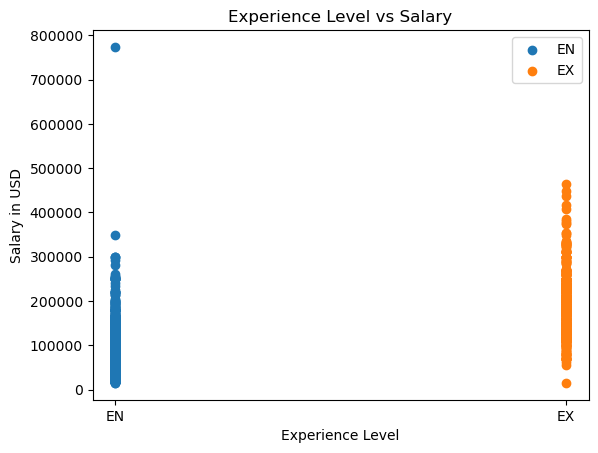

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# DO IT
df = pd.read_csv("DataScience_salaries_2024.csv")
df_EN = df[df["experience_level"] == "EN"]
df_EX = df[df["experience_level"] == "EX"]
plt.scatter(df_EN["experience_level"], df_EN["salary_in_usd"], label="EN")
plt.scatter(df_EX["experience_level"], df_EX["salary_in_usd"], label="EX")
plt.xlabel("Experience Level")
plt.ylabel("Salary in USD")
plt.title("Experience Level vs Salary")
plt.legend()
plt.show()

In the example above, we see an outlier in the data of entry-level individuals. This is actually a common use of scatter plots: to identify outliers.

**Exercise 01:** Generate the same graph, but this time let's filter out this outlier and add a line graph showing the average values per year. One line should represent entry-level individuals, and another should represent expert-level ones.

In [49]:
# TODO: Exercise 01
import pandas as pd
import matplotlib.pyplot as plt
# DO IT
df_EN = df[df["experience_level"] == "EN"]
df_EX = df[df["experience_level"] == "EX"]

**Exercise 02:** Now, let's explore the color bar, considering gas usage in America (`gas_usage.csv`). Let's create a scatter graph that relates gas consumption over the years in Florida by month. We aim to identify consumption trends according to the months.

To achieve this, let's use the 'c' color option and include a color bar. The final result should look like the graph below.

![nice_graph.png](nice_graph.png)

In [50]:
# TODO exercise 02



## Florida gas usage: why does it form two groups?

The scatter plot for Florida separates because the dataset mixes several different natural-gas delivery processes in the same chart. The cells below keep all of the analysis at the end of the notebook and use multiple views to check whether the split comes from month, year, or process category.


In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Load only Florida and create helper columns for plotting.
gas = pd.read_csv("gas_usage.csv")
florida = gas[gas["area-name"] == "FLORIDA"].copy()
florida["date"] = pd.to_datetime(dict(year=florida["year"], month=florida["month"], day=1))
florida["month_name"] = florida["date"].dt.strftime("%b")
florida["process_short"] = florida["process-name"].str.replace(" Consumption", "", regex=False)

process_order = florida.groupby("process-name")["value"].median().sort_values().index
summary = florida.groupby("process-name")["value"].agg(["count", "min", "median", "mean", "max"]).round(1)
summary.sort_values("median")


,count,min,median,mean,max
process-name,,,,,
Vehicle Fuel Consumption,121,22.0,381.0,307.4,541.0
Residential Consumption,121,593.0,1226.0,1432.4,3108.0
Commercial Consumption,121,3590.0,5074.0,5183.8,7129.0
Industrial Consumption,120,6957.0,9431.5,9417.3,12033.0
Electric Power Consumption,121,60860.0,101383.0,105278.5,158543.0
Delivered to Consumers,120,76417.0,118175.5,121583.6,174599.0


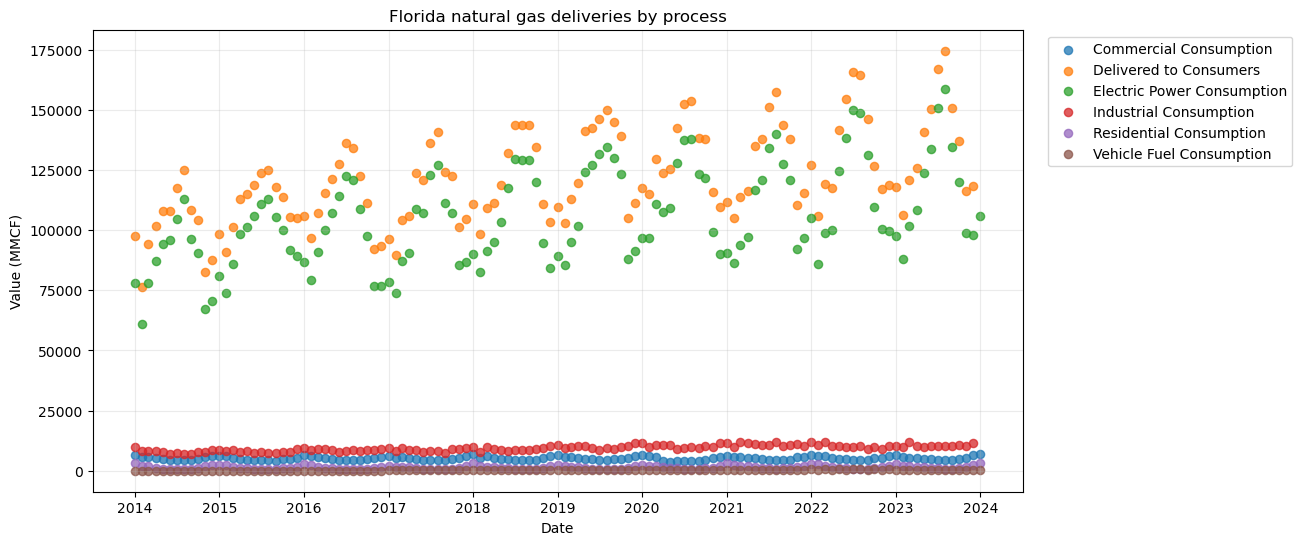

In [52]:
# First view: all Florida points together.
# The two upper bands are Electric Power and Delivered to Consumers.
plt.figure(figsize=(12, 6))
for process, data in florida.groupby("process-name"):
    plt.scatter(data["date"], data["value"], alpha=0.75, s=35, label=process)

plt.title("Florida natural gas deliveries by process")
plt.xlabel("Date")
plt.ylabel("Value (MMCF)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.25)
plt.show()


/var/folders/j0/_nt_yhqd1wsdc65yzzgxw4d00000gn/T/ipykernel_18129/2538787765.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


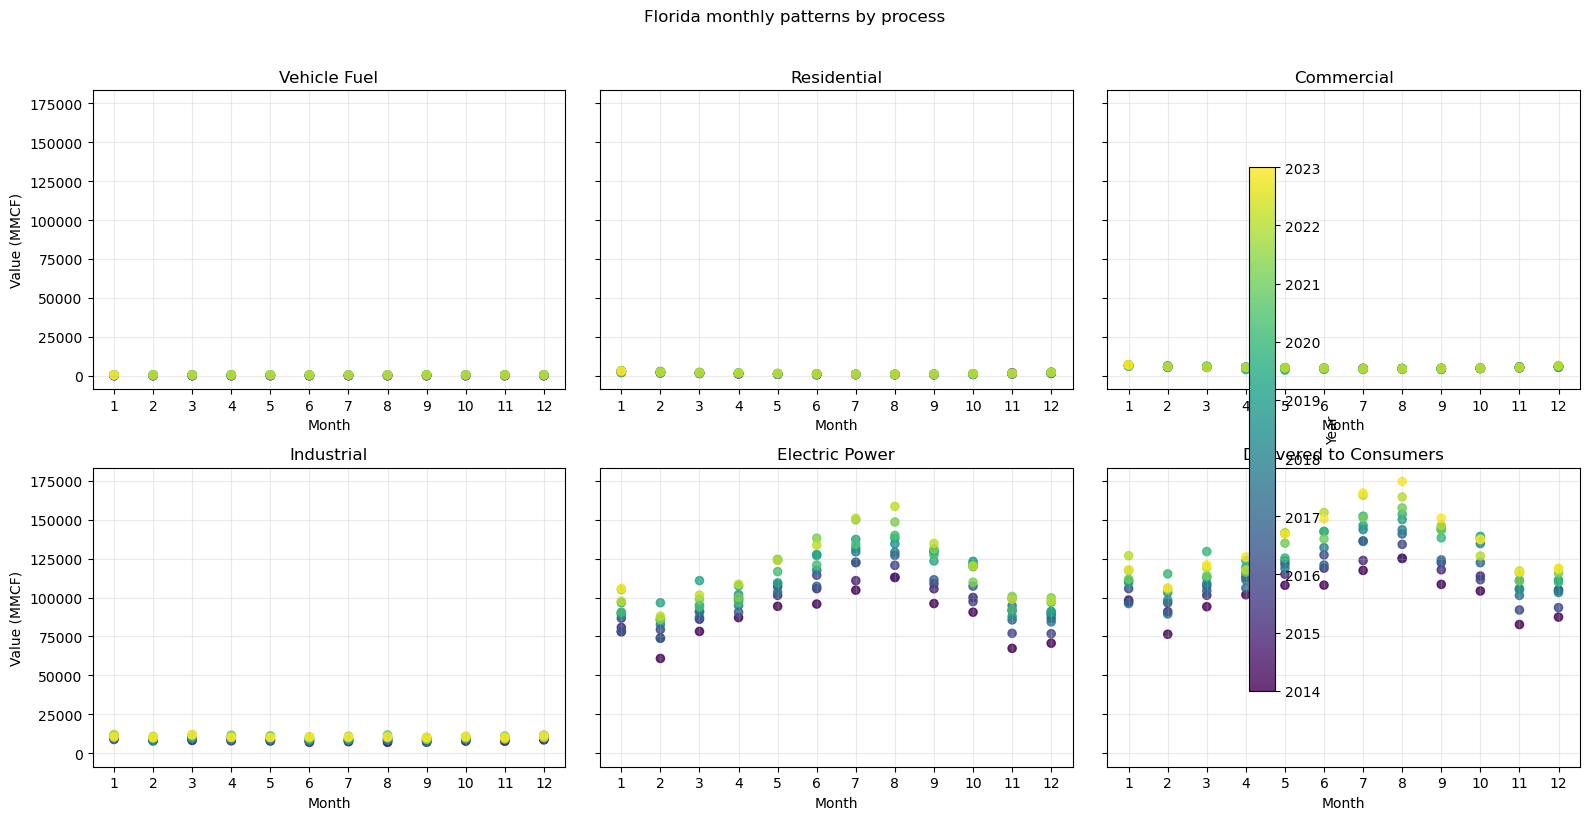

In [53]:
# Same data, but plotted against month and colored by year.
# This checks whether the split is seasonal. Seasonality exists, but it does not create the main two groups.
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for ax, process in zip(axes, process_order):
    data = florida[florida["process-name"] == process]
    scatter = ax.scatter(
        data["month"],
        data["value"],
        c=data["year"],
        cmap="viridis",
        alpha=0.8,
        s=35,
    )
    ax.set_title(process.replace(" Consumption", ""))
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Value (MMCF)")
axes[3].set_ylabel("Value (MMCF)")
fig.colorbar(scatter, ax=axes, label="Year", shrink=0.85)
fig.suptitle("Florida monthly patterns by process", y=1.02)
plt.tight_layout()
plt.show()


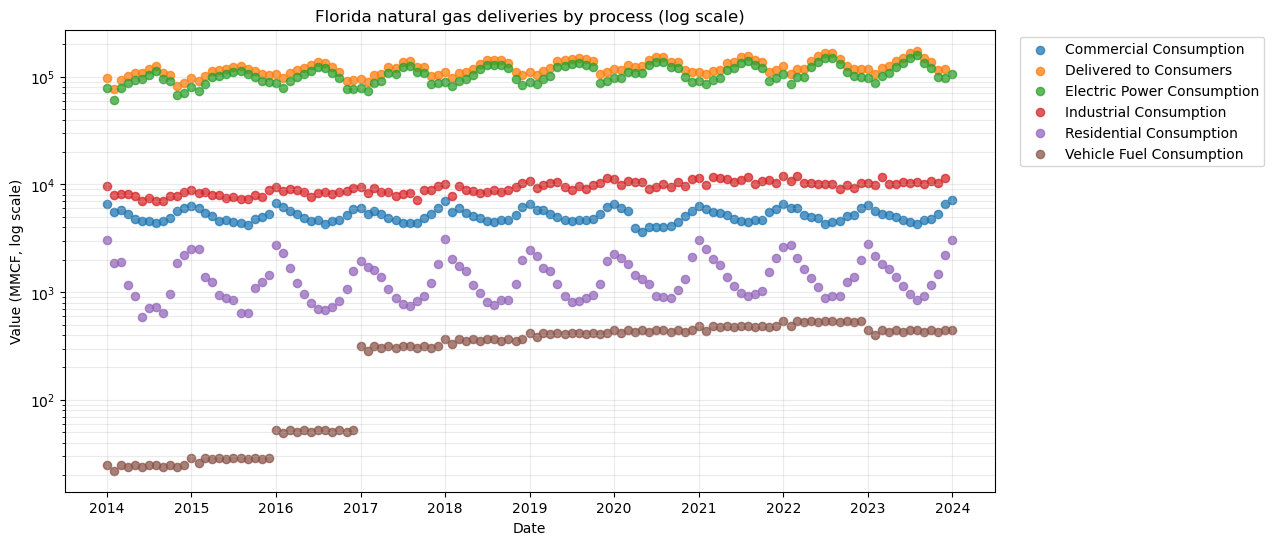

In [54]:
# Log scale makes the smaller processes visible.
# The vertical separation remains, confirming the groups are mostly caused by process size.
plt.figure(figsize=(12, 6))
for process, data in florida.groupby("process-name"):
    plt.scatter(data["date"], data["value"], alpha=0.75, s=35, label=process)

plt.yscale("log")
plt.title("Florida natural gas deliveries by process (log scale)")
plt.xlabel("Date")
plt.ylabel("Value (MMCF, log scale)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, which="both", alpha=0.25)
plt.show()


/var/folders/j0/_nt_yhqd1wsdc65yzzgxw4d00000gn/T/ipykernel_18129/4129752107.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showmeans=True)


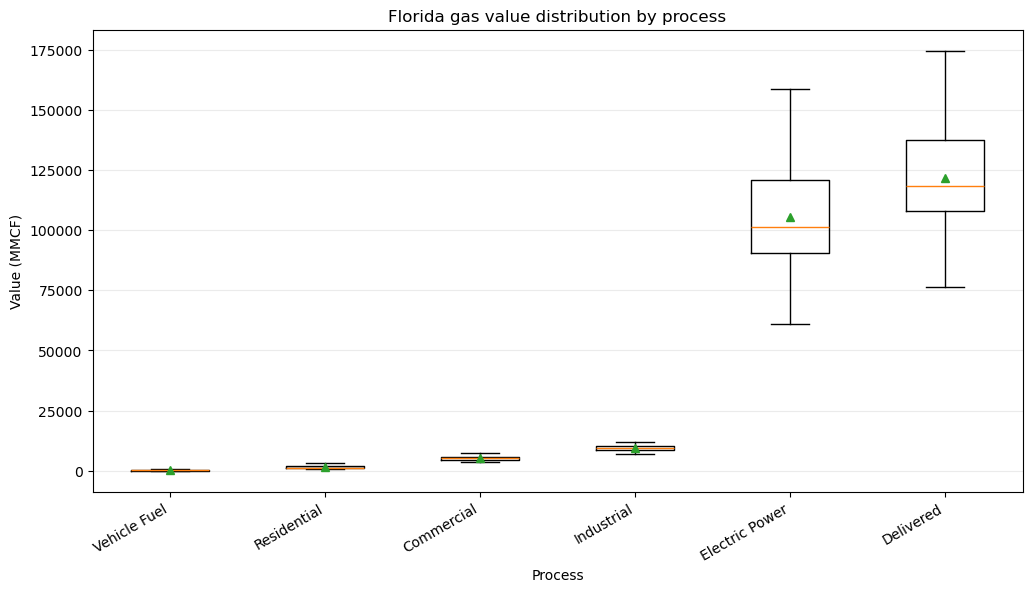

In [55]:
# Boxplot by process: this directly compares each process distribution.
plt.figure(figsize=(12, 6))
box_data = [florida.loc[florida["process-name"] == process, "value"].dropna() for process in process_order]
labels = [process.replace(" Consumption", "").replace("Delivered to Consumers", "Delivered") for process in process_order]

plt.boxplot(box_data, labels=labels, showmeans=True)
plt.xticks(rotation=30, ha="right")
plt.title("Florida gas value distribution by process")
plt.xlabel("Process")
plt.ylabel("Value (MMCF)")
plt.grid(True, axis="y", alpha=0.25)
plt.show()


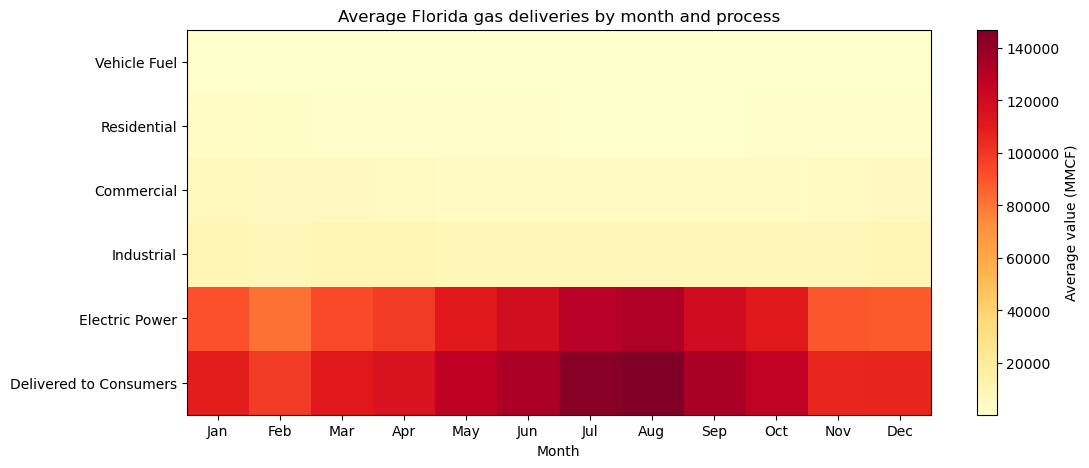

In [56]:
# Heatmap-style view: average month value for each process.
# Electric Power is highest in hot months, while Residential is highest in cooler months.
month_process = florida.pivot_table(
    index="process-name",
    columns="month",
    values="value",
    aggfunc="mean",
).loc[process_order]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(month_process, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(len(month_process.index)))
ax.set_yticklabels([p.replace(" Consumption", "") for p in month_process.index])
ax.set_xticks(range(12))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_title("Average Florida gas deliveries by month and process")
ax.set_xlabel("Month")
fig.colorbar(im, ax=ax, label="Average value (MMCF)")
plt.show()


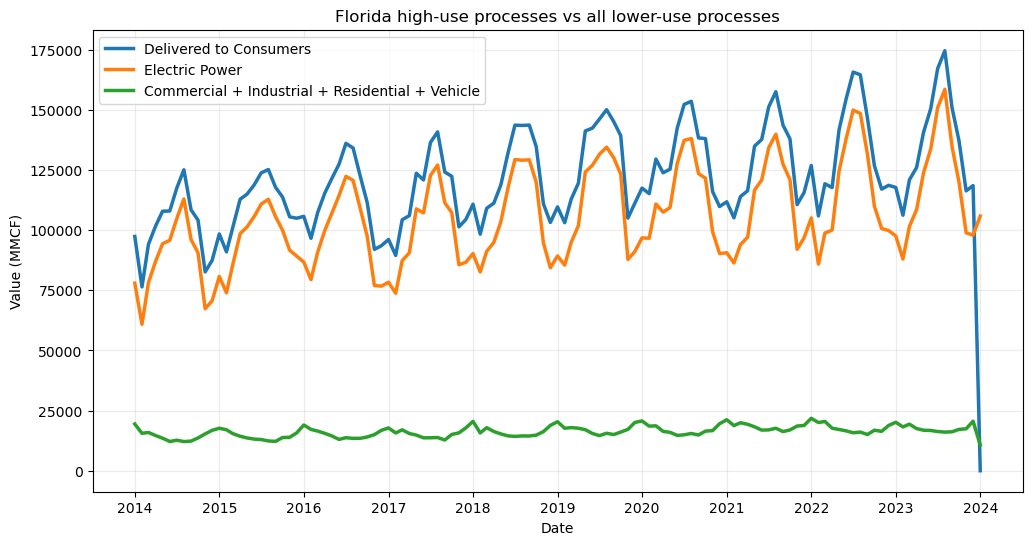

In [57]:
# Compare the high-use processes with the sum of all lower-use processes.
# Delivered to Consumers closely follows Electric Power because Electric Power dominates total deliveries.
pivot = florida.pivot_table(index="date", columns="process-name", values="value", aggfunc="sum").sort_index()
low_processes = [
    "Commercial Consumption",
    "Industrial Consumption",
    "Residential Consumption",
    "Vehicle Fuel Consumption",
]
pivot["Lower-use processes combined"] = pivot[low_processes].sum(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(pivot.index, pivot["Delivered to Consumers"], label="Delivered to Consumers", linewidth=2.5)
plt.plot(pivot.index, pivot["Electric Power Consumption"], label="Electric Power", linewidth=2.5)
plt.plot(pivot.index, pivot["Lower-use processes combined"], label="Commercial + Industrial + Residential + Vehicle", linewidth=2.5)
plt.title("Florida high-use processes vs all lower-use processes")
plt.xlabel("Date")
plt.ylabel("Value (MMCF)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


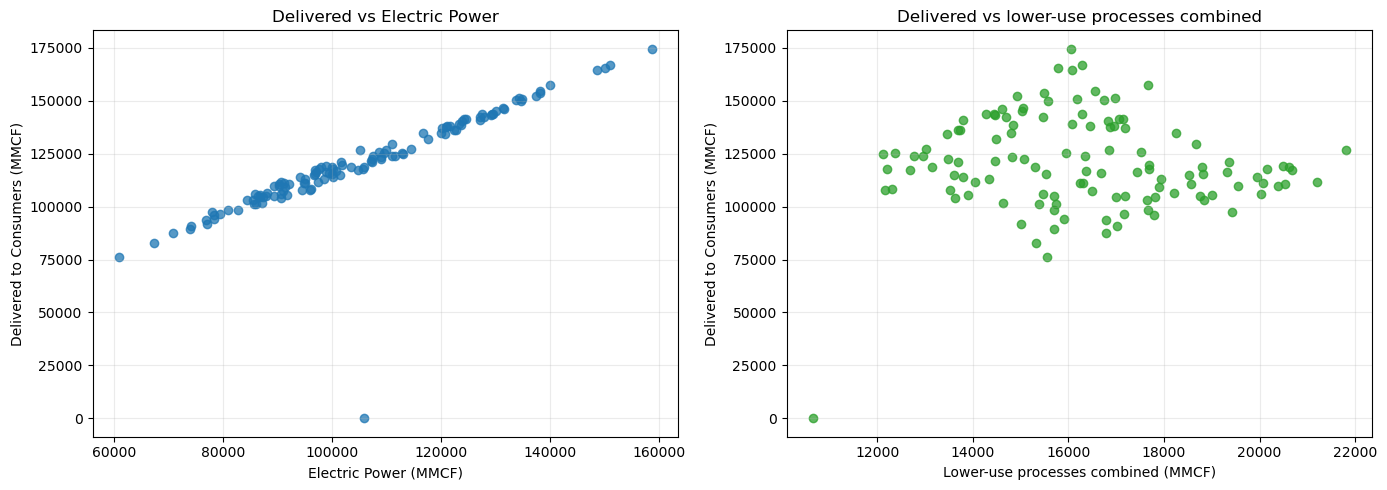

In [58]:
# Scatter the total-delivery series against its biggest component.
# A strong diagonal pattern means Electric Power explains much of the high cluster.
plot_data = pivot[["Delivered to Consumers", "Electric Power Consumption", "Lower-use processes combined"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(plot_data["Electric Power Consumption"], plot_data["Delivered to Consumers"], alpha=0.75)
axes[0].set_title("Delivered vs Electric Power")
axes[0].set_xlabel("Electric Power (MMCF)")
axes[0].set_ylabel("Delivered to Consumers (MMCF)")
axes[0].grid(True, alpha=0.25)

axes[1].scatter(plot_data["Lower-use processes combined"], plot_data["Delivered to Consumers"], alpha=0.75, color="tab:green")
axes[1].set_title("Delivered vs lower-use processes combined")
axes[1].set_xlabel("Lower-use processes combined (MMCF)")
axes[1].set_ylabel("Delivered to Consumers (MMCF)")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


In [59]:
# Simple numerical check for the cluster split.
# A threshold around 25,000 MMCF separates the two visible groups in this dataset.
threshold = 25_000
florida["cluster_size"] = florida["value"].apply(lambda v: "High group" if v >= threshold else "Low group")
cluster_check = pd.crosstab(florida["process-name"], florida["cluster_size"])
cluster_check


cluster_size,High group,Low group
process-name,,
Commercial Consumption,0,121
Delivered to Consumers,120,1
Electric Power Consumption,121,0
Industrial Consumption,0,121
Residential Consumption,0,121
Vehicle Fuel Consumption,0,121


In [60]:
print("Conclusion:")
print("The two clusters are mainly not a mystery of month or year.")
print("They happen because the chart combines processes with very different magnitudes.")
print("High group: Delivered to Consumers and Electric Power Consumption.")
print("Low group: Commercial, Industrial, Residential, and Vehicle Fuel Consumption.")
print("Seasonality still matters inside each process, especially Electric Power in summer and Residential in cooler months.")


Conclusion:
The two clusters are mainly not a mystery of month or year.
They happen because the chart combines processes with very different magnitudes.
High group: Delivered to Consumers and Electric Power Consumption.
Low group: Commercial, Industrial, Residential, and Vehicle Fuel Consumption.
Seasonality still matters inside each process, especially Electric Power in summer and Residential in cooler months.
